# Model Evaluation and Thresholding Action

This notebook evaluates the trained Isolation Forest model and tunes the anomaly threshold using F1-score.

The model is unsupervised, so fraud labels are not used to train it. Labels are used here only to choose an operational alert threshold and understand the false-positive vs false-negative trade-off.

## 1. Imports and Project Paths

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FEATURE_MATRIX_PATH = PROCESSED_DATA_DIR / "feature_matrix.csv"
LABELS_PATH = PROCESSED_DATA_DIR / "labels.csv"
MODEL_PATH = MODELS_DIR / "isolation_forest_model.pkl"
SCALER_PATH = MODELS_DIR / "feature_scaler.pkl"

THRESHOLD_METADATA_PATH = MODELS_DIR / "threshold_metadata.pkl"
EVALUATION_RESULTS_PATH = PROCESSED_DATA_DIR / "threshold_evaluation_results.csv"
FINAL_PREDICTIONS_PATH = PROCESSED_DATA_DIR / "final_predictions.csv"
PR_CURVE_PATH = FIGURES_DIR / "precision_recall_curve.png"
THRESHOLD_F1_PATH = FIGURES_DIR / "threshold_f1_scores.png"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Evaluation Configuration

In [2]:
@dataclass(frozen=True)
class ThresholdTuningConfig:
    """Configuration for threshold tuning."""

    percentile_start: float = 80.0
    percentile_end: float = 99.9
    threshold_count: int = 200
    target_metric: str = "f1_score"


config = ThresholdTuningConfig()
config

ThresholdTuningConfig(percentile_start=80.0, percentile_end=99.9, threshold_count=200, target_metric='f1_score')

## 3. Load Model, Scaler, and Features

In [3]:
def require_file(path: Path) -> None:
    """Raise a helpful error when a required pipeline artifact is missing."""
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")


def load_evaluation_inputs() -> tuple[pd.DataFrame, pd.Series, IsolationForest, StandardScaler]:
    """Load trained artifacts and evaluation data."""
    for path in [FEATURE_MATRIX_PATH, LABELS_PATH, MODEL_PATH, SCALER_PATH]:
        require_file(path)

    features = pd.read_csv(FEATURE_MATRIX_PATH)
    labels = pd.read_csv(LABELS_PATH).squeeze("columns").astype(int)
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    return features, labels, model, scaler


X, y, isolation_forest, scaler = load_evaluation_inputs()

print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution: {y.value_counts().sort_index().to_dict()}")
X.head()

Feature matrix shape: (10000, 6)
Label distribution: {0: 9700, 1: 300}


,hour_of_day,day_of_week,transaction_value,is_first_time_receiver,velocity_last_10min,amount_vs_user_avg
0,0,0,1487.51,1,1.0,1.000000
1,0,0,2711.60,1,1.0,1.219036
2,1,0,497.85,1,1.0,0.337527
3,1,0,3050.08,1,1.0,1.551246
4,1,0,5436.65,1,1.0,1.000000


## 4. Compute Anomaly Scores

In [4]:
def compute_anomaly_scores(
    model: IsolationForest,
    scaler: StandardScaler,
    features: pd.DataFrame,
) -> pd.DataFrame:
    """Compute model scores where higher anomaly_score means more suspicious."""
    scaled_features = scaler.transform(features)
    decision_scores = model.decision_function(scaled_features)
    default_predictions = model.predict(scaled_features)

    return pd.DataFrame(
        {
            "decision_score": decision_scores,
            "anomaly_score": -decision_scores,
            "default_prediction": default_predictions,
            "is_suspicious_default": (default_predictions == -1).astype(int),
        }
    )


score_dataset = compute_anomaly_scores(isolation_forest, scaler, X)
score_dataset["is_fraud"] = y.to_numpy()

score_dataset.describe().round(4)

,decision_score,anomaly_score,default_prediction,is_suspicious_default,is_fraud
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,0.1382,-0.1382,0.9400,0.0300,0.0300
std,0.0530,0.0530,0.3412,0.1706,0.1706
min,-0.1402,-0.2034,-1.0000,0.0000,0.0000
25%,0.1190,-0.1735,1.0000,0.0000,0.0000
50%,0.1506,-0.1506,1.0000,0.0000,0.0000
75%,0.1735,-0.1190,1.0000,0.0000,0.0000
max,0.2034,0.1402,1.0000,1.0000,1.0000


## 5. Default Threshold Evaluation

In [5]:
def print_evaluation_report(labels: pd.Series, predictions: pd.Series, title: str) -> None:
    """Print classification report and confusion matrix for fraud alerts."""
    print(title)
    print(classification_report(labels, predictions, target_names=["Normal", "Fraud"], zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(labels, predictions))


print_evaluation_report(
    labels=y,
    predictions=score_dataset["is_suspicious_default"],
    title="Default Isolation Forest Threshold Evaluation",
)

Default Isolation Forest Threshold Evaluation
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9700
       Fraud       0.94      0.94      0.94       300

    accuracy                           1.00     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       1.00      1.00      1.00     10000

Confusion matrix:
[[9682   18]
 [  18  282]]


## 6. Custom Threshold Tuning with F1-Score

In [6]:
def evaluate_thresholds(
    anomaly_scores: pd.Series,
    labels: pd.Series,
    config: ThresholdTuningConfig,
) -> pd.DataFrame:
    """Evaluate candidate thresholds and choose the best F1-score trade-off."""
    percentile_grid = np.linspace(
        config.percentile_start,
        config.percentile_end,
        config.threshold_count,
    )
    thresholds = np.percentile(anomaly_scores, percentile_grid)
    results = []

    for percentile, threshold in zip(percentile_grid, thresholds):
        predictions = (anomaly_scores >= threshold).astype(int)
        results.append(
            {
                "percentile": percentile,
                "threshold": threshold,
                "precision": precision_score(labels, predictions, zero_division=0),
                "recall": recall_score(labels, predictions, zero_division=0),
                "f1_score": f1_score(labels, predictions, zero_division=0),
                "flagged_transactions": int(predictions.sum()),
            }
        )

    return pd.DataFrame(results).sort_values("f1_score", ascending=False).reset_index(drop=True)


threshold_results = evaluate_thresholds(score_dataset["anomaly_score"], y, config)
best_result = threshold_results.iloc[0]
best_threshold = float(best_result["threshold"])

print(f"Best threshold: {best_threshold:.6f}")
print(f"Best F1-score: {best_result['f1_score']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")

threshold_results.head(10)

Best threshold: 0.009042
Best F1-score: 0.9492
Precision: 0.9655
Recall: 0.9333


,percentile,threshold,precision,recall,f1_score,flagged_transactions
0,97.1,9.042331e-03,0.965517,0.933333,0.949153,290
1,97.2,1.726249e-02,0.975000,0.910000,0.941379,280
2,97.0,-5.003813e-16,0.940000,0.940000,0.940000,300
3,96.9,-4.725077e-03,0.922581,0.953333,0.937705,310
4,96.8,-1.183971e-02,0.903125,0.963333,0.932258,320
5,97.3,2.428661e-02,0.977778,0.880000,0.926316,270
6,96.7,-1.371804e-02,0.881818,0.970000,0.923810,330
7,97.4,3.240736e-02,0.992308,0.860000,0.921429,260
8,96.6,-2.025858e-02,0.864706,0.980000,0.918750,340
9,97.5,4.150835e-02,1.000000,0.833333,0.909091,250


## 7. Final Threshold Evaluation

In [7]:
final_predictions = (score_dataset["anomaly_score"] >= best_threshold).astype(int)

print_evaluation_report(
    labels=y,
    predictions=final_predictions,
    title="Optimized Threshold Evaluation",
)

score_dataset["is_suspicious_optimized"] = final_predictions
score_dataset.head()

Optimized Threshold Evaluation
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9700
       Fraud       0.97      0.93      0.95       300

    accuracy                           1.00     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       1.00      1.00      1.00     10000

Confusion matrix:
[[9690   10]
 [  20  280]]


,decision_score,anomaly_score,default_prediction,is_suspicious_default,is_fraud,is_suspicious_optimized
0,0.113136,-0.113136,1,0,0,0
1,0.103800,-0.103800,1,0,0,0
2,0.096125,-0.096125,1,0,0,0
3,0.106898,-0.106898,1,0,0,0
4,0.087459,-0.087459,1,0,0,0


## 8. Precision-Recall and Threshold Plots

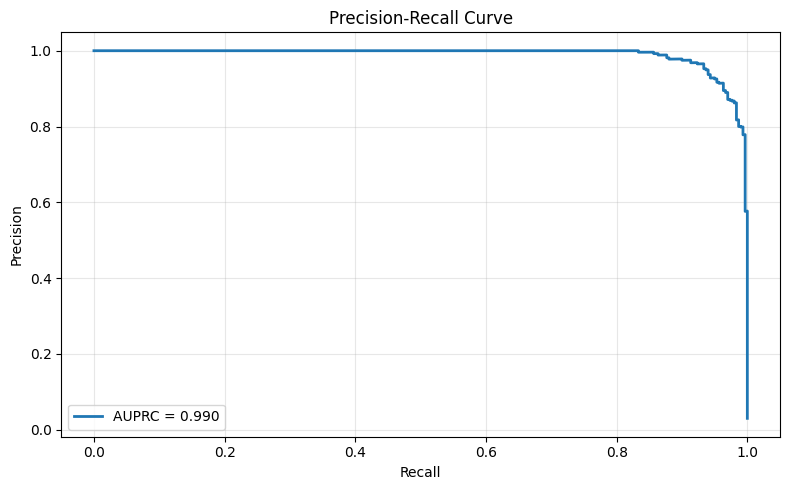

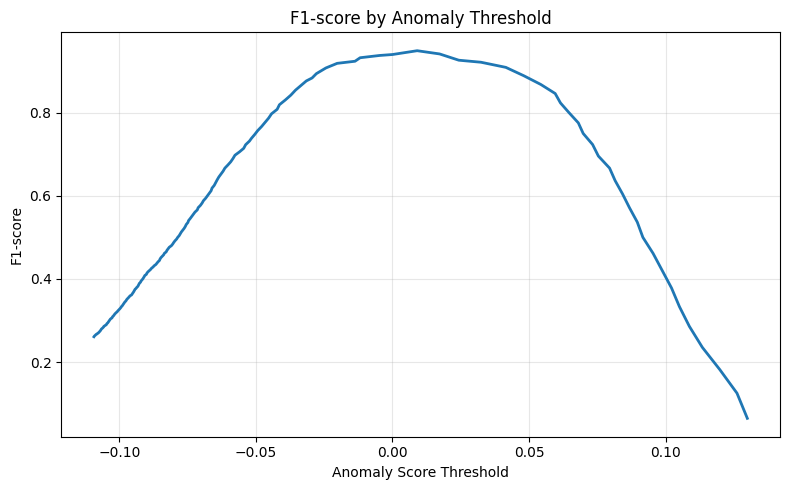

AUPRC: 0.9895


In [8]:
def plot_precision_recall_curve(labels: pd.Series, anomaly_scores: pd.Series, output_path: Path) -> float:
    """Plot and save the precision-recall curve."""
    precision, recall, _ = precision_recall_curve(labels, anomaly_scores)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 5))
    plt.plot(recall, precision, linewidth=2, label=f"AUPRC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    return float(pr_auc)


def plot_threshold_f1_scores(threshold_results: pd.DataFrame, output_path: Path) -> None:
    """Plot F1-score across candidate anomaly thresholds."""
    ordered_results = threshold_results.sort_values("threshold")

    plt.figure(figsize=(8, 5))
    plt.plot(ordered_results["threshold"], ordered_results["f1_score"], linewidth=2)
    plt.xlabel("Anomaly Score Threshold")
    plt.ylabel("F1-score")
    plt.title("F1-score by Anomaly Threshold")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


pr_auc = plot_precision_recall_curve(y, score_dataset["anomaly_score"], PR_CURVE_PATH)
plot_threshold_f1_scores(threshold_results, THRESHOLD_F1_PATH)

print(f"AUPRC: {pr_auc:.4f}")

## 9. Save Evaluation Artifacts

In [9]:
def save_evaluation_artifacts(
    threshold_results: pd.DataFrame,
    score_dataset: pd.DataFrame,
    best_result: pd.Series,
    pr_auc: float,
    config: ThresholdTuningConfig,
) -> dict[str, Path]:
    """Persist threshold tuning results for deployment and reporting."""
    metadata: dict[str, Any] = {
        "best_threshold": float(best_result["threshold"]),
        "best_percentile": float(best_result["percentile"]),
        "precision": float(best_result["precision"]),
        "recall": float(best_result["recall"]),
        "f1_score": float(best_result["f1_score"]),
        "flagged_transactions": int(best_result["flagged_transactions"]),
        "auprc": float(pr_auc),
        "config": asdict(config),
    }

    threshold_results.to_csv(EVALUATION_RESULTS_PATH, index=False)
    score_dataset.to_csv(FINAL_PREDICTIONS_PATH, index=False)
    joblib.dump(metadata, THRESHOLD_METADATA_PATH)

    return {
        "threshold_metadata": THRESHOLD_METADATA_PATH,
        "evaluation_results": EVALUATION_RESULTS_PATH,
        "final_predictions": FINAL_PREDICTIONS_PATH,
        "precision_recall_curve": PR_CURVE_PATH,
        "threshold_f1_scores": THRESHOLD_F1_PATH,
    }


saved_paths = save_evaluation_artifacts(threshold_results, score_dataset, best_result, pr_auc, config)

for artifact_name, artifact_path in saved_paths.items():
    print(f"Saved {artifact_name}: {artifact_path}")

Saved threshold_metadata: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\models\threshold_metadata.pkl
Saved evaluation_results: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\data\processed\threshold_evaluation_results.csv
Saved final_predictions: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\data\processed\final_predictions.csv
Saved precision_recall_curve: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\precision_recall_curve.png
Saved threshold_f1_scores: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\threshold_f1_scores.png


## 10. Output Summary

Generated files:

- `models/threshold_metadata.pkl`
- `data/processed/threshold_evaluation_results.csv`
- `data/processed/final_predictions.csv`
- `reports/figures/precision_recall_curve.png`
- `reports/figures/threshold_f1_scores.png`

The saved threshold can be used by the Streamlit dashboard to convert anomaly scores into real-time fraud alerts.